# [스프린트 미션 4] 딥러닝 기초 + PyTorch 문법 연습 (문제)

**딥러닝 기본기 · PyTorch 활용하기** 토픽에서 배운 내용을 바탕으로 문제를 풀어 보세요.

### 풀이 방법
- 각 문제의 `# TODO` 부분을 채워 주세요. `None`을 알맞은 코드로 바꾸면 됩니다.
- 문제 아래의 **[확인]** 셀을 실행해서 통과 메시지(✅)가 나오는지 확인하세요.
- 제출 전 **[런타임] → [모두 실행]** 으로 처음부터 끝까지 오류 없이 실행되는지 꼭 확인하세요.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
print("PyTorch version:", torch.__version__)

PyTorch version: 2.14.0+cpu


## Part 1. 기초

### 기초 1. 텐서 생성
0부터 11까지의 정수를 순서대로 담은 **(3, 4) 크기의 float32 텐서** `t1`을 만들어 주세요.

> 힌트: `torch.arange()`, `reshape()`(또는 `view()`), `dtype`

In [3]:
# TODO: t1을 완성하세요.
t1 = torch.arange(0,12)
t1 = t1.reshape(3,4)
t1 = t1.float()
print(t1.dtype)
print(t1)

torch.float32
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])


In [4]:
# [확인] 기초 1
assert t1.shape == (3, 4), f"shape이 다릅니다: {t1.shape}"
assert t1.dtype == torch.float32, f"dtype이 다릅니다: {t1.dtype}"
assert t1[0, 0] == 0 and t1[2, 3] == 11, "값이 다릅니다."
print("기초 1 통과! ✅")

기초 1 통과! ✅


### 기초 2. 인덱싱과 슬라이싱
텐서 `t2`에서 다음 세 가지를 추출하세요.
- `row2`: 세 번째 행 (인덱스 2)
- `col_last`: 마지막 열
- `sub`: 1~2행, 1~3열 부분 텐서 → shape `(2, 3)`

In [5]:
t2 = torch.arange(20).reshape(4, 5)
print(t2)

tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]])


In [6]:
# TODO: 세 변수를 완성하세요.
row2 = t2[2,:]
col_last = t2[:,-1]
#sub = t2[0:2, 0:3]
sub = t2[1:3, 1:4]

print(row2, col_last, sub, sep="\n")

tensor([10, 11, 12, 13, 14])
tensor([ 4,  9, 14, 19])
tensor([[ 6,  7,  8],
        [11, 12, 13]])


In [7]:
# [확인] 기초 2
assert torch.equal(row2, torch.tensor([10, 11, 12, 13, 14]))
assert torch.equal(col_last, torch.tensor([4, 9, 14, 19]))
assert sub.shape == (2, 3) and sub[0, 0] == 6 and sub[1, 2] == 13
print("기초 2 통과! ✅")

기초 2 통과! ✅


### 기초 3. 모양 바꾸기 — squeeze, unsqueeze, reshape 
텐서 `t3`의 모양을 아래와 같이 바꿔 보세요.
- `a`: `t3`에서 크기가 1인 차원을 제거해 `(3, 4)`로
- `b`: `a`의 **맨 뒤에** 크기 1인 차원을 추가해 `(3, 4, 1)`로
- `c`: `t3`의 데이터를 `(2, 6)` 모양으로 재배열

In [8]:
t3 = torch.randn(3, 1, 4)
print(t3.shape)
print(t3)

torch.Size([3, 1, 4])
tensor([[[ 0.3367,  0.1288,  0.2345,  0.2303]],

        [[-1.1229, -0.1863,  2.2082, -0.6380]],

        [[ 0.4617,  0.2674,  0.5349,  0.8094]]])


In [9]:
# TODO: 세 변수를 완성하세요.
a = t3.squeeze(dim=1)
print(a.shape)
b = a.unsqueeze(dim=2)
print(b.shape)
c = b.reshape(2,6)
print(c.shape)

print(a.shape, b.shape, c.shape)

torch.Size([3, 4])
torch.Size([3, 4, 1])
torch.Size([2, 6])
torch.Size([3, 4]) torch.Size([3, 4, 1]) torch.Size([2, 6])


In [10]:
# [확인] 기초 3
assert a.shape == (3, 4)
assert b.shape == (3, 4, 1)
assert c.shape == (2, 6)
assert torch.equal(c.flatten(), t3.flatten()), "c는 t3와 같은 데이터를 담아야 합니다."
print("기초 3 통과! ✅")

기초 3 통과! ✅


### 기초 4. 타입 캐스팅 
- `t4_long`: `t4`를 정수(`long`) 타입으로 변환 (소수점 버림 → `[1, 2, 3]`)
- `t4_float`: `t4_long`을 다시 `float32`로 변환

In [11]:
t4 = torch.tensor([1.7, 2.3, 3.9])
print(t4, t4.dtype)

tensor([1.7000, 2.3000, 3.9000]) torch.float32


In [12]:
# TODO: 두 변수를 완성하세요.
t4_long = t4.long()
t4_float = t4_long.float()

print(t4_long, t4_long.dtype)
print(t4_float, t4_float.dtype)

tensor([1, 2, 3]) torch.int64
tensor([1., 2., 3.]) torch.float32


In [13]:
# [확인] 기초 4
assert t4_long.dtype == torch.int64
assert torch.equal(t4_long, torch.tensor([1, 2, 3]))
assert t4_float.dtype == torch.float32
print("기초 4 통과! ✅")

기초 4 통과! ✅


### 기초 5. 텐서 이어붙이기 — cat과 stack 
`a5`(2×3, 전부 1)와 `b5`(2×3, 전부 0)를 이어붙여 보세요.
- `cat0`: dim=0 방향으로 이어붙이기 → `(4, 3)`
- `cat1`: dim=1 방향으로 이어붙이기 → `(2, 6)`
- `stacked`: **새로운 차원**을 만들어 쌓기 → `(2, 2, 3)`

> `cat`은 기존 차원을 따라 이어붙이고, `stack`은 차원을 하나 새로 만든다는 차이를 확인해 보세요.

In [14]:
a5 = torch.ones(2, 3)
b5 = torch.zeros(2, 3)
print(a5)
print(b5)

tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [15]:
# TODO: 세 변수를 완성하세요.
cat0 = torch.cat([a5,b5], dim=0)
cat1 = torch.cat([a5,b5], dim=1)
stacked = torch.stack([a5, b5], dim=0)

print(cat0.shape, cat1.shape, stacked.shape)

torch.Size([4, 3]) torch.Size([2, 6]) torch.Size([2, 2, 3])


In [16]:
# [확인] 기초 5
assert cat0.shape == (4, 3)
assert cat1.shape == (2, 6)
assert stacked.shape == (2, 2, 3)
print("기초 5 통과! ✅")

기초 5 통과! ✅


### 기초 6. 행렬곱과 원소곱 
- `mm`: `m1`(2×3)과 `m2`(3×4)의 **행렬곱** → `(2, 4)`
- `ew`: `m1`과 `m3`(2×3)의 **원소별 곱** → `(2, 3)`

In [17]:
m1 = torch.tensor([[1., 2., 3.],
                   [4., 5., 6.]])
m2 = torch.ones(3, 4)
m3 = torch.full((2, 3), 2.)
print(m1)
print(m2)
print(m3)

tensor([[1., 2., 3.],
        [4., 5., 6.]])
tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
tensor([[2., 2., 2.],
        [2., 2., 2.]])


In [18]:
# TODO: 두 변수를 완성하세요.
mm = m1 @ m2 
ew = m1 * m3

print(mm, ew, sep="\n")

tensor([[ 6.,  6.,  6.,  6.],
        [15., 15., 15., 15.]])
tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.]])


In [19]:
# [확인] 기초 6
assert mm.shape == (2, 4) and mm[0, 0] == 6 and mm[1, 0] == 15
assert ew.shape == (2, 3) and torch.equal(ew, m1 * 2)
print("기초 6 통과! ✅")

기초 6 통과! ✅


### 기초 7. Autograd로 기울기 구하기 
함수 $y = x^2 + 3x$ 의 $x = 2$ 에서의 기울기를 autograd로 구하세요.

수학적으로 $\frac{dy}{dx} = 2x + 3$ 이므로, $x=2$에서의 기울기는 **7**입니다.
- `x`: 값이 2.0이고 `requires_grad=True`인 텐서
- `y`를 계산하고 역전파를 수행
- `grad`: `x`에 저장된 기울기

In [20]:
# TODO: autograd로 기울기를 계산하세요.
x = torch.tensor(2.0, requires_grad=True)
print(x)
y = (x **2) + 3*x
# (역전파 수행)
y.backward()

grad = x.grad 
print(grad)

tensor(2., requires_grad=True)
tensor(7.)


In [21]:
# [확인] 기초 7
assert grad is not None and grad.item() == 7.0, f"기울기가 다릅니다: {grad}"
print("기초 7 통과! ✅")

기초 7 통과! ✅


### 기초 8. 활성화 함수 
딥러닝 기본기에서 배운 활성화 함수를 직접 적용해 보세요.
- `relu_out`: `z`에 **ReLU** 적용 (음수는 0으로)
- `sig_out`: `z`에 **Sigmoid** 적용 (0~1 사이 값으로)
- `probs`: `logits`에 **Softmax**를 적용해 확률 분포로 (합이 1)

In [22]:
z = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
logits = torch.tensor([1.0, 2.0, 3.0])
print(z)
print(logits)

tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])
tensor([1., 2., 3.])


In [23]:
# TODO: 세 변수를 완성하세요.
relu_out = F.relu(z)
sig_out = F.sigmoid(z)
probs = F.softmax(logits, dim=0)

print(relu_out, sig_out, probs, sep="\n")

tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])
tensor([0.1192, 0.3775, 0.5000, 0.6225, 0.8808])
tensor([0.0900, 0.2447, 0.6652])


In [24]:
# [확인] 기초 8
assert torch.equal(relu_out, torch.tensor([0.0, 0.0, 0.0, 0.5, 2.0]))
assert abs(sig_out[2].item() - 0.5) < 1e-6, "Sigmoid(0)은 0.5여야 합니다."
assert abs(probs.sum().item() - 1.0) < 1e-6, "Softmax 결과의 합은 1이어야 합니다."
assert probs.argmax().item() == 2
print("기초 8 통과! ✅")

기초 8 통과! ✅


### 기초 9. 텐서를 device로 옮기기 
GPU가 있으면 GPU를, 없으면 CPU를 사용하도록 device를 설정하고 텐서를 옮겨 보세요.
- `device`: GPU 사용 가능 시 `"cuda"`, 아니면 `"cpu"`
- `t9_dev`: `t9`를 `device`로 옮긴 텐서

> 이렇게 작성해 두면 같은 코드가 GPU 유무와 관계없이 동작합니다. 모델과 데이터를 같은 device에 두는 습관은 미션 5부터 계속 쓰게 돼요.

In [25]:
t9 = torch.randn(2, 2)
print(t9)
print(t9.device.type)

tensor([[ 1.1103, -1.6898],
        [-0.9890,  0.9580]])
cpu


In [26]:
# TODO: 두 변수를 완성하세요.
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.device(device)

t9_dev = t9.to(device)

print(f"사용 중인 device: {device}")

사용 중인 device: cpu


In [27]:
# [확인] 기초 9
expected = "cuda" if torch.cuda.is_available() else "cpu"
assert device == expected
assert t9_dev.device.type == expected
print("기초 9 통과! ✅")

기초 9 통과! ✅


## Part 2. 심화

### 심화 1. 손실 함수 — 직접 계산 vs 내장 함수 
- `mse_manual`: MSE 공식(오차 제곱의 평균) 그대로 직접 계산
- `mse_builtin`: `nn.MSELoss`를 사용해 계산 → 두 값이 같은지 확인
- `ce`: 분류 문제용 — `logits2`와 정수 라벨 `labels`로 `nn.CrossEntropyLoss` 계산

> ⚠️ `CrossEntropyLoss`는 내부에 Softmax가 포함되어 있어 모델 출력(logits)을 **그대로** 넣어야 하고, 라벨은 원-핫이 아닌 **정수(long)** 여야 합니다.

In [28]:
pred = torch.tensor([2.5, 0.0, 2.0])
target = torch.tensor([3.0, -0.5, 2.0])

logits2 = torch.tensor([[2.0, 0.5, 0.3],
                        [0.2, 2.5, 0.1]])
labels = torch.tensor([0, 1])

In [29]:
# TODO: 세 변수를 완성하세요.
mse_manual = ((pred - target) **2).mean()
mse_builtin = F.mse_loss(pred, target)
ce = F.cross_entropy(logits2, labels)

print(mse_manual, mse_builtin, ce, sep="\n")

tensor(0.1667)
tensor(0.1667)
tensor(0.2577)


In [30]:
# [확인] 심화 1
assert torch.allclose(mse_manual, mse_builtin), "직접 계산한 MSE와 내장 함수 결과가 달라요."
assert abs(mse_manual.item() - 1/6) < 1e-6, f"MSE 값이 다릅니다: {mse_manual}"
assert ce.item() > 0
print("심화 1 통과! ✅")

심화 1 통과! ✅


### 심화 2. Autograd만으로 선형 회귀 학습하기 
`nn.Module` 없이 **순수 autograd**만으로 $y = 2x + 1$ 데이터를 학습해 보세요.

채워야 할 곳 (4곳):
1. 예측값 계산: $\hat{y} = xw + b$
2. 역전파 수행
3. 경사 하강법으로 `w`, `b` 갱신 (`w -= lr * w.grad` 형태)
4. `w`, `b`의 기울기를 0으로 초기화

> 파라미터 갱신은 `with torch.no_grad():` 안에서 해야 합니다. 갱신 자체가 연산 그래프에 기록되면 안 되기 때문이에요.

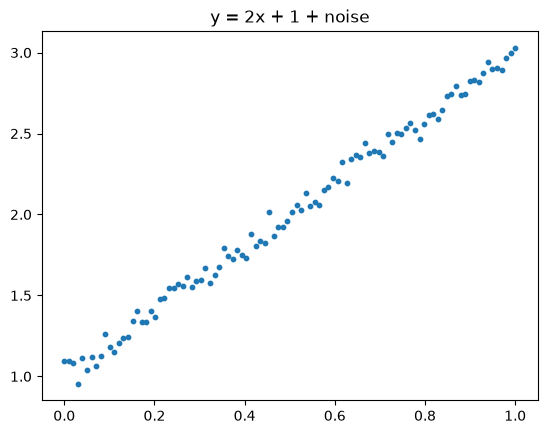

In [31]:
# y = 2x + 1 에 약간의 노이즈를 섞은 데이터
torch.manual_seed(42)
x2 = torch.linspace(0, 1, 100).unsqueeze(1)
y2 = 2 * x2 + 1 + 0.05 * torch.randn(100, 1)
# print(x2.shape)
# print(y2.shape)

plt.scatter(x2, y2, s=10) #
plt.title("y = 2x + 1 + noise")
plt.show()

In [32]:
lr = 0.3
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

# print("1. w.grad",w.grad)
# print("1. b.grad", b.grad)

losses2 = []
for step in range(500):
    # TODO 1: 예측값을 계산하세요.
    y_hat = w * x2 + b

    # print("2. w.grad",w.grad)
    # print("2. b.grad", b.grad)

    loss = ((y_hat - y2) ** 2).mean()
    losses2.append(loss.item())

    # print("3. w.grad",w.grad)
    # print("3. b.grad", b.grad)

    # TODO 2: 역전파를 수행하세요.
    loss.backward()

    # print("4. w.grad",w.grad)
    # print("4. b.grad", b.grad)

    with torch.no_grad():
        # TODO 3: 경사 하강법으로 w와 b를 갱신하세요.
        # print(w.grad)
        # print(b.grad)
        w -= lr * w.grad 
        b -= lr * b.grad 

    # TODO 4: w와 b의 기울기를 0으로 초기화하세요.
    w.grad.zero_()
    b.grad.zero_()


print(f"학습된 w: {w.item():.3f} (정답: 2)")
print(f"학습된 b: {b.item():.3f} (정답: 1)")
print(f"최종 손실: {losses2[-1]:.5f}")

학습된 w: 1.997 (정답: 2)
학습된 b: 1.004 (정답: 1)
최종 손실: 0.00241


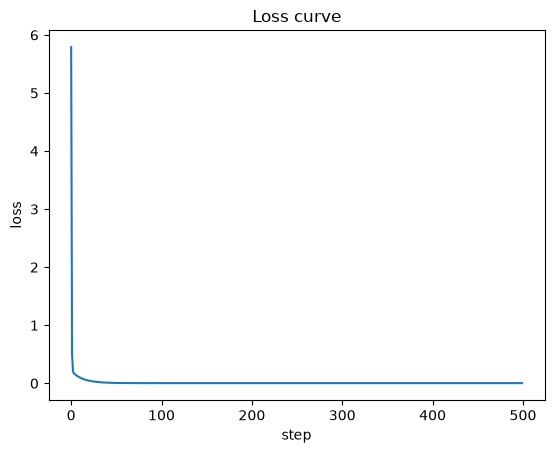

심화 2 통과! ✅


In [33]:
# [확인] 심화 2
assert abs(w.item() - 2) < 0.2, f"w가 2에 충분히 가깝지 않습니다: {w.item():.3f}"
assert abs(b.item() - 1) < 0.2, f"b가 1에 충분히 가깝지 않습니다: {b.item():.3f}"
assert losses2[-1] < 0.02

plt.plot(losses2)
plt.xlabel("step"); plt.ylabel("loss"); plt.title("Loss curve")
plt.show()
print("심화 2 통과! ✅")

### 심화 3. nn.Module로 선형 회귀 구현하기 
심화 2와 같은 문제를 이번에는 **PyTorch 표준 방식**(`nn.Module` + `optimizer`)으로 풀어 보세요.

채워야 할 곳 (2곳):
1. `__init__`: 입력 1차원 → 출력 1차원의 선형 층 (`nn.Linear`)
2. `forward`: 입력을 선형 층에 통과시켜 반환

학습 코드는 완성된 상태로 제공됩니다. 학습 후 `model.linear.weight`와 `bias`가 정답(2와 1)에 가까워졌는지, 그리고 `nn.Linear`의 파라미터가 자동으로 등록되는 것을 확인해 보세요.

In [34]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO 1: 입력 1차원 -> 출력 1차원 선형 층을 정의하세요.
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        # TODO 2: 입력을 선형 층에 통과시켜 반환하세요.
        return self.linear(x)


# --- 아래 학습 코드는 수정하지 않아도 됩니다 ---
torch.manual_seed(42)
model3 = LinearRegression()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model3.parameters(), lr=0.3)

for epoch in range(500):
    optimizer.zero_grad()
    loss = criterion(model3(x2), y2)
    loss.backward()
    optimizer.step()

print(f"학습된 weight: {model3.linear.weight.item():.3f} (정답: 2)")
print(f"학습된 bias  : {model3.linear.bias.item():.3f} (정답: 1)")

# nn.Module이 파라미터를 자동으로 관리해 주는 것을 확인해 보세요.
for name, p in model3.named_parameters():
    print(name, p.shape, type(p).__name__)

학습된 weight: 1.997 (정답: 2)
학습된 bias  : 1.004 (정답: 1)
linear.weight torch.Size([1, 1]) Parameter
linear.bias torch.Size([1]) Parameter


In [35]:
# [확인] 심화 3
assert isinstance(model3.linear, nn.Linear)
assert abs(model3.linear.weight.item() - 2) < 0.2
assert abs(model3.linear.bias.item() - 1) < 0.2
print("심화 3 통과! ✅")

심화 3 통과! ✅


### 심화 4. 2층 MLP 분류 모델 만들기 
초승달 모양의 2차원 데이터(`make_moons`)를 분류하는 **2층 MLP**를 만들어 보세요.

모델 구조 (딥러닝 기본기의 다층 퍼셉트론 그대로입니다):
- `fc1`: 입력 2차원 → 은닉 **16**차원 선형 층
- `fc2`: 은닉 16차원 → 출력 **2**차원(클래스 수) 선형 층
- `forward`: 입력 → `fc1` → **ReLU** → `fc2` → 반환

> ⚠️ 출력에 Softmax를 붙이지 마세요. 심화 1에서 확인했듯 `CrossEntropyLoss`가 내부에서 처리합니다.

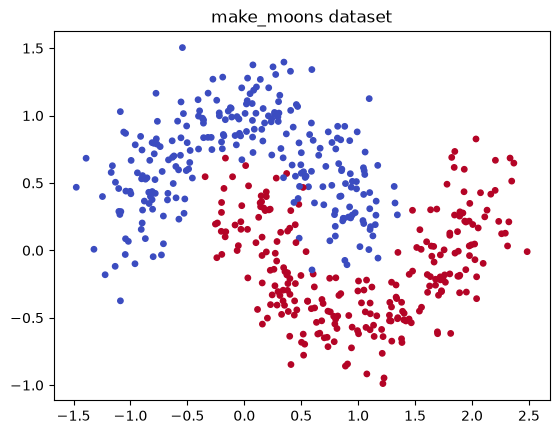

torch.Size([500, 2]) torch.Size([500])


In [36]:
from sklearn.datasets import make_moons

X_np, y_np = make_moons(n_samples=500, noise=0.2, random_state=42)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=15)
plt.title("make_moons dataset")
plt.show()
print(X.shape, y.shape)

In [37]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO 1: 두 개의 선형 층을 정의하세요. (2 -> 16, 16 -> 2)
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):
        # TODO 2: fc1 -> ReLU -> fc2 순서로 통과시켜 반환하세요.
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x) 
        return x


model4 = MLP()
print(model4)

MLP(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)


In [38]:
a = X[:5]
print(a)
m = model4(a)
print(m)

tensor([[ 0.8309, -0.3343],
        [ 0.9917,  0.8790],
        [ 1.1072, -0.4703],
        [-0.1409,  1.0331],
        [ 0.4056,  1.3285]])
tensor([[ 0.4719, -0.2138],
        [ 0.3204, -0.2915],
        [ 0.5780, -0.2099],
        [-0.1280, -0.5484],
        [-0.0473, -0.3602]], grad_fn=<AddmmBackward0>)


In [39]:
# [확인] 심화 4
out = model4(X[:5])
assert out.shape == (5, 2), f"출력 shape이 다릅니다: {out.shape}"
n_params = sum(p.numel() for p in model4.parameters())
assert n_params == 82, f"파라미터 수가 다릅니다: {n_params} (2*16+16 + 16*2+2 = 82여야 해요)"
print("심화 4 통과! ✅")

심화 4 통과! ✅


### 심화 5. 학습 루프 완성하기 
심화 4에서 만든 MLP를 학습시키는 루프를 완성하세요. 학습 루프의 5단계를 순서대로 채우면 됩니다.

1. 기울기 초기화 (`optimizer.zero_grad()`)
2. 순전파 — 모델에 `X`를 넣어 logits 계산
3. 손실 계산 (`criterion` 사용)
4. 역전파 (`loss.backward()`)
5. 파라미터 갱신 (`optimizer.step()`)

In [40]:
torch.manual_seed(42)
model5 = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model5.parameters(), lr=0.01)

losses5 = []
for epoch in range(300):
    # TODO 1: 기울기 초기화
    optimizer.zero_grad()
    # TODO 2: 순전파
    logits = model5.forward(X)

    # TODO 3: 손실 계산
    loss = criterion(logits, y)

    # TODO 4: 역전파
    loss.backward()

    # TODO 5: 파라미터 갱신
    optimizer.step()

    losses5.append(loss.item())

print(f"최종 손실: {losses5[-1]:.4f}")

최종 손실: 0.0670


학습 정확도: 0.980


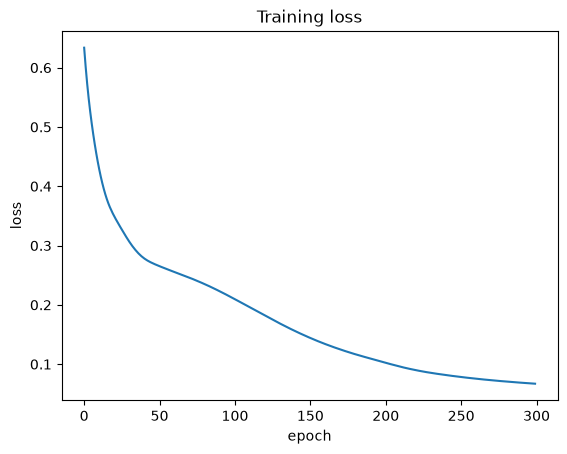

심화 5 통과! ✅


In [41]:
# [확인] 심화 5
with torch.no_grad():
    acc = (model5(X).argmax(dim=1) == y).float().mean().item()
print(f"학습 정확도: {acc:.3f}")
assert acc > 0.85, "정확도가 너무 낮습니다. 학습 루프를 다시 확인해 보세요."

plt.plot(losses5)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Training loss")
plt.show()
print("심화 5 통과! ✅")

### 심화 6. DataLoader로 미니배치 학습 
심화 5에서는 전체 데이터(500개)를 한 번에 넣었지만, 실전에서는 데이터를 **미니배치**로 나눠 학습합니다.

채워야 할 곳:
1. `TensorDataset`으로 `X`, `y`를 묶어 `dataset` 생성
2. `DataLoader`로 `batch_size=64`, `shuffle=True`인 `loader` 생성
3. 배치(`xb`)로 순전파하고 배치 라벨(`yb`)로 손실 계산

In [42]:
from torch.utils.data import TensorDataset, DataLoader

In [43]:
# TODO 1, 2: dataset과 loader를 생성하세요.
dataset = TensorDataset(X, y)
loader = DataLoader(dataset=dataset, batch_size=64, shuffle=True)

torch.manual_seed(42)
model6 = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model6.parameters(), lr=0.01)

losses6 = []
for epoch in range(100):
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()

        # TODO 3: 배치 데이터로 순전파하고 손실을 계산하세요.
        logits = model6(X)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    losses6.append(epoch_loss / len(dataset))

print(f"최종 손실: {losses6[-1]:.4f}")

최종 손실: 0.0445


In [44]:
# [확인] 심화 6
assert len(dataset) == 500
assert loader.batch_size == 64
assert len(loader) == 8, "500개를 배치 64로 나누면 8개 배치가 나와야 합니다."
with torch.no_grad():
    acc6 = (model6(X).argmax(dim=1) == y).float().mean().item()
print(f"학습 정확도: {acc6:.3f}")
assert acc6 > 0.85
print("심화 6 통과! ✅")

학습 정확도: 0.984
심화 6 통과! ✅


### 심화 7. 옵티마이저와 학습률 실험 
같은 모델·데이터라도 **옵티마이저와 학습률**에 따라 학습이 크게 달라집니다. 아래 제공된 `train_with` 함수로 네 가지 설정을 학습시키고 손실 곡선을 비교해 보세요.

| 설정 | 옵티마이저 | 학습률 |
|---|---|---|
| ① | SGD | 0.01 |
| ② | SGD | 0.5 |
| ③ | SGD | 10.0 |
| ④ | Adam | 0.01 |

In [45]:
def train_with(optimizer_fn, epochs=200):
    """주어진 옵티마이저 설정으로 새 MLP를 학습시키고 손실 기록을 반환합니다."""
    torch.manual_seed(0)
    model = MLP()
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_fn(model.parameters())
    losses = []
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

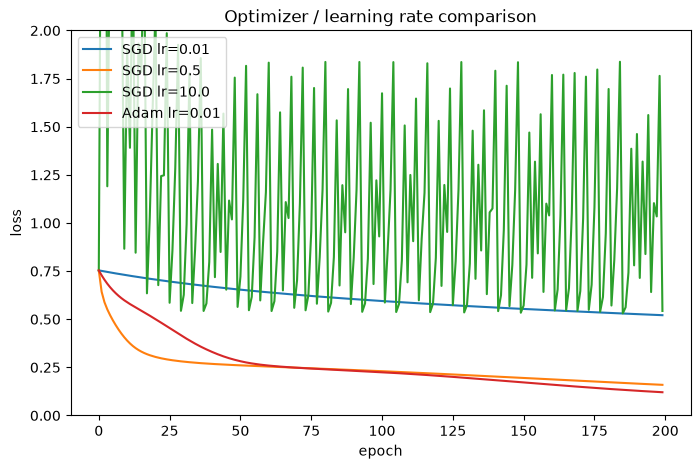

In [46]:
results = {}
# TODO: 네 가지 설정으로 학습시키세요.
# 예시: results["SGD lr=0.01"] = train_with(lambda p: torch.optim.SGD(p, lr=0.01))
results["SGD lr=0.01"] = train_with(lambda p: torch.optim.SGD(p, lr=0.01) )
results["SGD lr=0.5"] = train_with(lambda p: torch.optim.SGD(p, lr=0.5) )
results["SGD lr=10.0"] = train_with(lambda p: torch.optim.SGD(p, lr=10.0))
results["Adam lr=0.01"] = train_with(lambda p: torch.optim.Adam(p, lr=0.01))

# --- 아래 시각화 코드는 수정하지 않아도 됩니다 ---
plt.figure(figsize=(8, 5))
for name, losses in results.items():
    plt.plot(losses, label=name)
plt.xlabel("epoch"); plt.ylabel("loss")
plt.ylim(0, 2)
plt.legend(); plt.title("Optimizer / learning rate comparison")
plt.show()

In [47]:
# [확인] 심화 7
assert all(v is not None and len(v) == 200 for v in results.values()), "네 설정 모두 학습시켜야 합니다."
print("심화 7 통과! ✅ (아래 서술 문제까지 작성해야 완료입니다)")

심화 7 통과! ✅ (아래 서술 문제까지 작성해야 완료입니다)


### 심화 7 — 서술 문제
위 손실 곡선을 보고 아래 질문에 답해 주세요. (다음 마크다운 셀에 작성)

1. 가장 빠르고 안정적으로 수렴한 설정은 무엇인가요?
2. `SGD lr=10.0`에서는 어떤 일이 일어났나요? 딥러닝 기본기에서 배운 내용을 바탕으로 **이유**를 설명해 주세요.
3. Adam이 SGD와 다른 점은 무엇인가요? (힌트: 모멘텀, RMSProp)

**답변을 여기에 작성해 주세요.**

1. Adam lr=0.01 설정이 가장 빠르고 안정적으로 수렴합니다.

2. 학습률이 너무 커서 가중치 업데이트가 오버슈팅되며 손실 값이 발산하는 현상이 발생했습니다. 학습률이 경사면의 골짜기 폭보다 크기 때문에, 아래로 내려가지 못하고 반대편 언덕을 향해 나가면서 솔실 값이 수렴하지 못하고 요동치게 된 것입니다.

3. SGD는 고정된 방향과 보폭으로만 움직이지만, Adam은 관성 모멘텀과 기울기의 크기(RMSProp)에 따라 보폭을 유현하게 줄이거나 늘리는 장점이 있어 스스로 방향과 속도를 조절합니다.
